In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
# %matplotlib inline

import numpy as np
from sklearn.linear_model import LinearRegression
from time import time

ch.set_printoptions(precision=4, sci_mode=False)

In [2]:
def generate_data(phi, num_samples, W, NOISE_VAR, W0=0, D=1, verbose=False):
    current_time_seed = int(time() * 1000)
    ch.manual_seed(current_time_seed)
    a, b = 0, 1
    
    x_trunc, y_trunc = ch.Tensor([]), ch.Tensor([])
    X, Y = ch.Tensor([]), ch.Tensor([])
    sampled = 0
    while x_trunc.size(0) < num_samples:
        x = (b - a) * ch.rand(num_samples, D) + a
                
        y = x @ W + W0 + (NOISE_VAR ** .5) * ch.randn(num_samples, 1)
        
        X = ch.cat([X, x])
        Y = ch.cat([Y, y])
        
        trunc_indices = phi(y).flatten().nonzero().flatten()

        y_trunc = ch.cat([y_trunc, y[trunc_indices]]) 
        x_trunc = ch.cat([x_trunc, x[trunc_indices]])
        sampled += num_samples

    alpha = x_trunc.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return x_trunc[:num_samples], y_trunc[:num_samples], alpha, X, Y

D = 2
W = ch.ones(D, 1)
NOISE_VAR = 1.0
def phi(x): 
    return x > 2

x_trunc, y_trunc, alpha, X, Y = generate_data(phi, 1000, W, NOISE_VAR, D=D, verbose=True)

alpha: 0.177


In [3]:
print(f"truncated coefficient: {LinearRegression(fit_intercept=False).fit(x_trunc, y_trunc).coef_}")

print(f"ground truth coefficient: {LinearRegression(fit_intercept=False).fit(X, Y).coef_}")

truncated coefficient: [[1.9575177 1.9500302]]
ground truth coefficient: [[0.973986 1.000926]]


In [4]:
import pandas as pd

df = pd.DataFrame({ 
    "x1": x_trunc[:,0].flatten().numpy(), 
    "x2": x_trunc[:,1].flatten().numpy(),
    "y": y_trunc.flatten().numpy()
})

In [5]:
cols = df.columns.tolist()
cols.remove('y')

formula_string = ["y ~"] + [col for col in cols] 
if True:
    formula_string = formula_string + ["0"]
new_string = ' + '.join(formula_string)
new_string[:3] + new_string[5:]

'y ~ x1 + x2 + 0'

In [6]:
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
import rpy2.robjects as ro
from rpy2.robjects import Formula
import pandas as pd
from rpy2.robjects import pandas2ri

# import the R package
truncreg = importr("truncreg")

def run_truncreg(df, cutoff, with_intercept=True, scale=False):
    with (ro.default_converter + pandas2ri.converter).context():
        r_from_pd_df = ro.conversion.get_conversion().py2rpy(df)
    robjects.r('''
               f <- function(train, formula, cutoff, scale) {

                        library(truncreg)
                        train1.truncreg <- truncreg(
                                        formula,
                                        data=train,
                                        point=cutoff, 
                                        direction='left',
                                        scale=scale
                                    )


                }
                ''')
    r_truncreg = robjects.globalenv['f']
    
    cols = df.columns.tolist()
    cols.remove('y')

    formula_string = ["y ~"] + [col for col in cols] 
    if not with_intercept:
        formula_string = formula_string + ["0"]
    new_string = ' + '.join(formula_string)
    
    formula = new_string[:3] + new_string[5:]
    
    formula = Formula(new_string[:3] + new_string[5:])  
    return r_truncreg(r_from_pd_df, formula, cutoff, scale)

In [7]:
truncreg_model=run_truncreg(df, 2, with_intercept=False)
truncreg_model.rx('coefficients')[0]

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  


1.074195,0.848080,0.999267


# One Dimension Regression - Varying Samples

In [8]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1500, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 1500
W fit:
 [1.0612849]


In [9]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

X_trunc_mu = X_trunc.mean(0)
X_trunc_var = X_trunc.var(0)

X_trunc_std = (X_trunc - X_trunc_mu) / (X_trunc_var ** .5)
X_std = (X - X_trunc_mu) / (X_trunc_var ** .5)

trunc_lin_reg = LinearRegression(fit_intercept=True)
trunc_lin_reg.fit(X_trunc_std, Y_trunc)

gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X_std, Y)

W_fit = np.concatenate([gt_lin_reg.coef_, gt_lin_reg.intercept_.reshape(1,)])
trunc_lin_reg_coef = np.concatenate([trunc_lin_reg.coef_, trunc_lin_reg.intercept_.reshape(1,1)])
print(f'W fit:\n {W_fit}')

print(f'trunc lin reg W:\n {trunc_lin_reg_coef}')

alpha:
 0.687
W fit:
 [0.29754525 0.5221944 ]
trunc lin reg W:
 [[0.19356199]
 [0.9975683 ]]


<IPython.core.display.Javascript object>


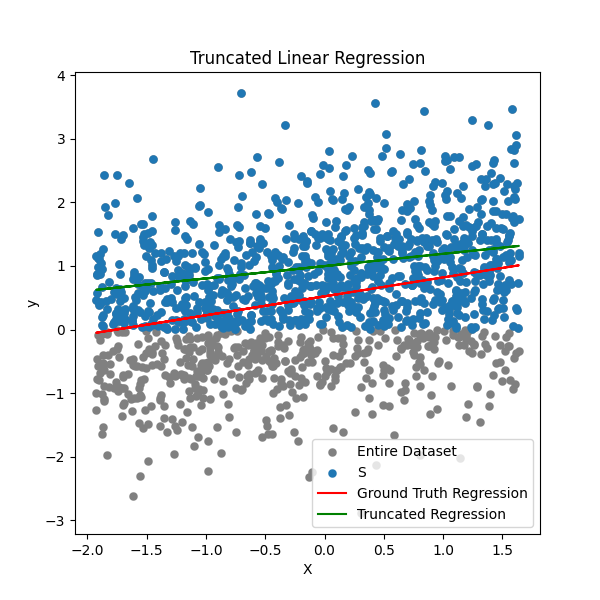

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X_std, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc_std, Y_trunc, linewidths=.1, label='S')
ax.plot(X_std.sort()[0], gt_lin_reg.predict(X_std.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X_std.sort()[0], trunc_lin_reg.predict(X_std.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

In [22]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 0

W = ch.ones(1, 1)
NOISE_VAR = 1.0

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
NUM_TRIALS = 10

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, NOISE_VAR)
        
        x_trunc_mu, x_trunc_var = x_trunc.mean(0), x_trunc.var(0)
        x_trunc_std = (x_trunc - x_trunc_mu) / (x_trunc_var ** .5)
        
        X_std = (X - x_trunc_mu) / (x_trunc_var ** .5)
        
        gt = LinearRegression(fit_intercept=True)
        gt.fit(X_std, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))
        gt_noise_var = ch.from_numpy(gt.predict(X_std) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=True)
        ols_trunc.fit(x_trunc_std, y_trunc)
        emp_noise_var = ch.from_numpy(ols_trunc.predict(x_trunc_std) - y_trunc.numpy()).var(0)
            
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))
        emp_mse_loss = mse_loss(emp_, gt_).item()
        emp_var_l1 = float(ch.abs(emp_noise_var - gt_noise_var))
        
#         def phi_emp_scale(X): 
#             return X > ((0 - ols_trunc.intercept_) / emp_noise_var ** .5)

#         y_trunc_emp_scale = (y_trunc - ols_trunc.intercept_) / ch.sqrt(emp_noise_var)

        args = Parameters({
                            'trials': 1,
                            'batch_size': 50,
                            'var_lr': 1e-1, 
                            'lr': 1e-1,
                            'early_stopping': True,
                            'step_lr_gamma': .95,
                            'gradient_steps': max(1500*3, num_samples),
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi,
                                                alpha, 
                                                fit_intercept=True)
        delphi_reg.fit(x_trunc_std, y_trunc)

        delphi_coef_ = ch.cat([delphi_reg.best_coef_.flatten(), delphi_reg.best_intercept_[...,None]]) 
        delphi_var_ = delphi_reg.best_variance_

        delphi_mse = mse_loss(gt_, delphi_coef_.flatten()).item()
        delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))
        
        df = pd.DataFrame({ 
            'y': y_trunc.flatten(), 
            'x1': x_trunc_std.flatten()
        })
        
        truncreg_results = run_truncreg(df, 0, with_intercept=True, scale=False)
        res = truncreg_results.rx('coefficients')[0]
        
        truncreg_coef_ = ch.Tensor(res[:-1])
        truncreg_var_ = ch.Tensor([res[-1]]).pow(2)
        
        truncreg_mse = mse_loss(gt_, truncreg_coef_).item()
        truncreg_var_l1 = float(ch.abs(truncreg_var_ - gt_noise_var))

        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'emp_var_l1': emp_var_l1, 
            'delphi_mse': delphi_mse, 
            'delphi_var_l1': delphi_var_l1, 
            'truncreg_mse': truncreg_mse,
            'truncreg_var_l1': truncreg_var_l1
        }
        results.append(result)
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
trial: 1, num samples: 500
trial: 1, num samples: 1000
trial: 1, num samples: 2000
trial: 1, num samples: 3000
trial: 1, num samples: 4000
trial: 1, num samples: 5000
trial: 1, num samples: 6000
trial: 1, num samples: 7000
trial: 1, num samples: 8000
trial: 1, num samples: 9000
trial: 1, num samples: 10000
trial: 2, num samples: 100
trial: 2, num samples: 500
trial: 2, num samples: 1000
trial: 2, num samples: 2000
trial: 2, num samples: 3000
trial: 2, num samples: 4000
trial: 2, num samples: 5000
trial: 2, num samples: 6000
trial: 2, num samples: 7000
trial: 2, num samples: 8000
trial: 2, num samples: 9000
trial: 2, num samples: 10000
trial: 3, num samples: 100
trial: 3, num samples: 500
trial: 3, num samples: 1000
trial: 3, num samples: 2000
trial: 3, num samples: 3000
trial: 3, num samples: 4000
trial: 3, num samples: 5000
trial: 3, num samples: 6000
trial: 3, num samples: 7000
trial: 3, num samples: 8000
trial: 3, num samples: 9000
trial: 3, num samples: 1

<IPython.core.display.Javascript object>


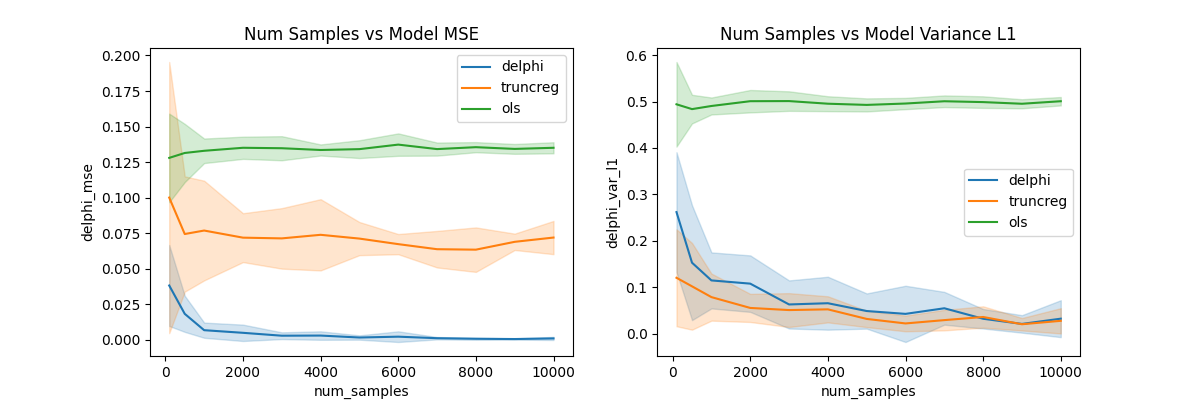

In [23]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi")
sns.lineplot(data=df, x="num_samples", y="truncreg_mse", estimator="mean", errorbar="sd", ax=ax1, label="truncreg")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax1, label="ols")
ax1.set_title('Num Samples vs Model MSE')

sns.lineplot(data=df, x="num_samples", y="delphi_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="delphi")
sns.lineplot(data=df, x="num_samples", y="truncreg_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="truncreg")
sns.lineplot(data=df, x="num_samples", y="emp_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="ols")
ax2.set_title('Num Samples vs Model Variance L1')

plt.show()

In [ ]:
# === Parameter grids ===
V_values = ch.linspace(.1, 3, 25)
lambda_values = ch.linspace(.1, 3, 25)
V_, LAMBDA_ = ch.meshgrid(V_values, lambda_values)


# === Compute NLL over the grid ===
Z = np.zeros_like(V_)
GRAD_V = ch.zeros_like(V_)
GRAD_LAMBDA_ = ch.zeros_like(LAMBDA_)
for i in range(len(V_values)):
    for j in range(len(lambda_values)):
        lambda_ = LAMBDA_[i, j]
        V_temp =  V_[i, j].reshape(1, 1)
        V_temp.requires_grad = True

        trunc_pred = X_trunc@(V_temp/lambda_)
        trunc_pred.retain_grad()
        loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, lambda_, phi)
    
        grad_ = (pred_grad / lambda_ * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_V[i, j] = grad_[0]
        GRAD_LAMBDA_[i, j] = lambda_grad

In [24]:
df[df['num_samples'] == 100]

,num_samples,emp_mse,emp_var_l1,delphi_mse,delphi_var_l1,truncreg_mse,truncreg_var_l1
0,100,0.084364,0.428239,0.000691,0.139171,0.065627,0.007024
12,100,0.128384,0.491121,0.044683,0.270361,0.269142,0.143004
24,100,0.202073,0.693371,0.009574,0.279796,0.002918,0.029431
36,100,0.124543,0.566378,0.045206,0.241218,0.013704,0.041758
48,100,0.133294,0.480694,0.083905,0.464927,0.022405,0.111436
60,100,0.100914,0.381216,0.012591,0.127059,0.103886,0.186805
72,100,0.119515,0.474309,0.023596,0.165753,0.107789,0.026752
84,100,0.129038,0.408272,0.028496,0.120016,0.011319,0.093929
96,100,0.144390,0.555043,0.079489,0.449900,0.218941,0.236990
108,100,0.112945,0.462085,0.053336,0.360711,0.184410,0.326863


In [205]:
delphi_reg.emp_noise_var

tensor([[0.9978]])

In [195]:
mse_loss(((x_trunc_std@delphi_reg.coef_) + delphi_reg.intercept_)[...,None], y_trunc_emp_scale[...,None])

/home/patroklos/base/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([10000, 1, 1])) that is different to the input size (torch.Size([10000, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(4.4780)

In [24]:
delphi_var_ = 1.0/delphi_reg.trainer.best_params[-1]
(delphi_reg.trainer.best_params[0] * delphi_var_ / delphi_reg.beta) * emp_noise_var ** .5

tensor([0.3903])

In [80]:
delphi_coef_ / (X_trunc_var ** .5) + X_trunc_mu

tensor([1.7844])

In [81]:
emp_ / (X_trunc_var ** .5) + X_trunc_mu

tensor([1.0121])

In [92]:
gt_ / X_trunc_var ** .5

tensor([0.7408])

In [88]:
phi_emp_scale(y_trunc_emp_scale)

tensor([[True],
        [True],
        [True],
        ...,
        [True],
        [True],
        [True]])

In [99]:
LinearRegression(fit_intercept=False).fit(X, y).coef_

array([[1.0038893]], dtype=float32)

In [101]:
print(LinearRegression(fit_intercept=False).fit(X, y).coef_)
print(f'W * X_trunc_var ** .5): {W * X_trunc_var ** .5}')
print(f'gt_: {gt_ / (X_trunc_var ** .5)}')

[[1.0038893]]
W * X_trunc_var ** .5): tensor([[0.2849]])
gt_: tensor([0.7408])


tensor([[ 1.3938,  1.0000],
        [ 1.4675,  1.0000],
        [-1.3929,  1.0000],
        ...,
        [-1.6805,  1.0000],
        [-0.0110,  1.0000],
        [-1.6865,  1.0000]])

In [202]:
from delphi.grad import TruncatedUnknownVarianceMSE
trunc_mse = TruncatedUnknownVarianceMSE.apply
print(f'truncated estimates loss: {trunc_mse(ch.cat([x_trunc_std, ch.ones_like(x_trunc_std)], dim=1)@delphi_coef_[...,None], y_trunc, 1/delphi_var_, phi).sum()}')
print(f'gt loss: {trunc_mse(ch.cat([x_trunc_std, ch.ones_like(x_trunc_std)], dim=1)@gt_[...,None], y_trunc, 1/ch.Tensor([gt_noise_var]), phi).sum()}')

truncated estimates loss: 1.071020245552063
gt loss: 0.9327412843704224


In [71]:
delphi_reg.train_loader.dataset.tensors[0].norm(dim=1, p=float('inf')).max()

tensor(1.)

In [36]:
LinearRegression(fit_intercept=False).fit(X_std, y).coef_

array([[0.2039996]], dtype=float32)

In [48]:
(LinearRegression(fit_intercept=False).fit((X - x_trunc.mean(0)) / (x_trunc.var(0) ** .5), y).coef_+ x_trunc.mean(0).numpy()) * (x_trunc.var(0).numpy() ** .5) 

array([[0.21456294]], dtype=float32)

In [51]:
x_trunc.var(0) ** .5

tensor([0.2869])

In [13]:
mse_loss(delphi_coef_, gt_)

tensor(0.0372)

In [ ]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 0

W = ch.ones(1, 1)
NOISE_VAR = 1.0

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
NUM_TRIALS = 10

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, NOISE_VAR)

        gt = LinearRegression(fit_intercept=False)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten()]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=False)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_noise_var = ch.from_numpy(ols_trunc.predict(x_trunc) - y_trunc.numpy()).var(0)
        
        def phi_emp_scale(X): 
                return X > (0 / emp_noise_var ** .5)
            
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten()]))

        emp_mse_loss = mse_loss(emp_, gt_).item()
        emp_var_l1 = float(ch.abs(emp_noise_var - gt_noise_var))

        y_trunc_emp_scale = y_trunc / ch.sqrt(emp_noise_var)

        args = Parameters({
                            'trials': 1,
                            'batch_size': -1,
                            'var_lr': None, 
                            'early_stopping': True,
#                             'step_lr': 1.0,
                            'epochs': 10,
                            'optimizer': 'lbfgs', 
                            'lbfgs_lr': 5e-1,
                            'verbose': True
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi_emp_scale,
                                                alpha, 
                                                fit_intercept=False)
        delphi_reg.fit(x_trunc, y_trunc_emp_scale)

        delphi_coef_ = delphi_reg.best_coef_ * (emp_noise_var ** .5)
        delphi_var_ = delphi_reg.best_variance_ * emp_noise_var

        delphi_mse = mse_loss(gt_, delphi_coef_.flatten()).item()
        delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))


        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'emp_var_l1': emp_var_l1, 
            'delphi_mse': delphi_mse, 
            'delphi_var_l1': delphi_var_l1
        }

        results.append(result)
    
    
df = pd.DataFrame(results)

<IPython.core.display.Javascript object>


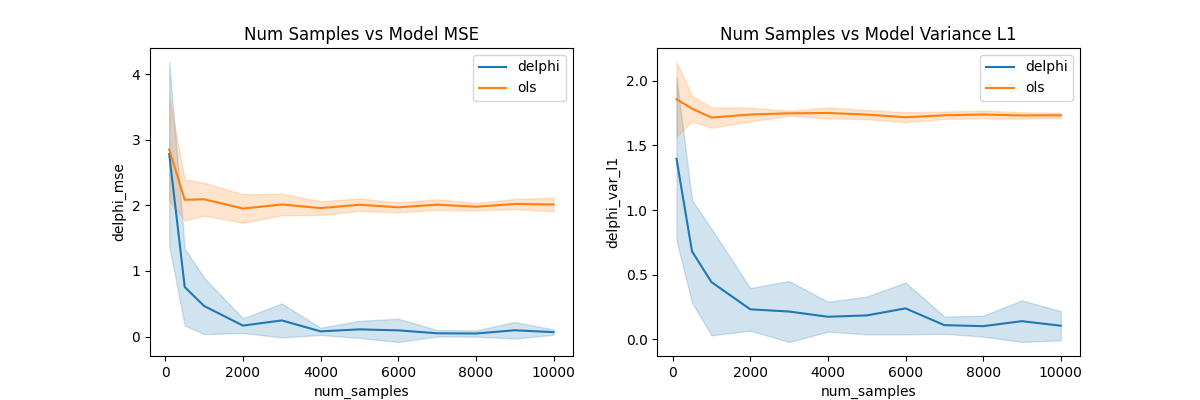

In [13]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax1, label="ols")
ax1.set_title('Num Samples vs Model MSE')

sns.lineplot(data=df, x="num_samples", y="delphi_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="ols")
ax2.set_title('Num Samples vs Model Variance L1')

plt.show()

# 10 Dimension Truncated Regression - Varying Samples

In [11]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 2.5

D = 5
W = ch.ones(D, 1)
W0 = ch.ones(1, 1)
NOISE_VAR = 3.0

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
# NUM_SAMPLES = [500] + [1000*i for i in range(1, 11)]

NUM_TRIALS = 1

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, NOISE_VAR, W0=W0, D=D, verbose=True)
        
        x_trunc_mu, x_trunc_var = x_trunc.mean(0), x_trunc.var(0)
        x_trunc_std = (x_trunc - x_trunc_mu) / (x_trunc_var ** .5)
        
        X_std = (X - x_trunc_mu) / (x_trunc_var ** .5)
        
        gt = LinearRegression(fit_intercept=True)
        gt.fit(X_std, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))
        gt_noise_var = ch.from_numpy(gt.predict(X_std) - y.numpy()).var(0)
        
        gt_orig = gt_[:-1] / ch.sqrt(x_trunc_var)
        gt_intercept_orig = gt_[-1] - (gt_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum()
        gt_orig_ = ch.cat([gt_orig, gt_intercept_orig.reshape(1,)])

        ols_trunc = LinearRegression(fit_intercept=True)
        ols_trunc.fit(x_trunc_std, y_trunc)
        emp_noise_var = ch.from_numpy(ols_trunc.predict(x_trunc_std) - y_trunc.numpy()).var(0)
            
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))
        
        emp_orig = emp_[:-1] / ch.sqrt(x_trunc_var)
        emp_intercept_orig = emp_[-1] - (emp_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum()
        emp_orig_ = ch.cat([emp_orig, emp_intercept_orig.reshape(1,)])
        
        emp_mse_loss = mse_loss(emp_orig_, gt_orig_).item()
        emp_var_l1 = float(ch.abs(emp_noise_var - gt_noise_var))

        args = Parameters({
                            'trials': 1,
                            'batch_size': 50,
                            'var_lr': 1e-2,
                            'lr': 1e-1,
                            'early_stopping': True,
                            'step_lr_gamma': .95,
                            'step_lr': 1000,
                            'num_samples': 1000,
                            'optimizer': 'sgd',
                            'gradient_steps': max(1500, num_samples),
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi,
                                                alpha, 
                                                fit_intercept=True)
        delphi_reg.fit(x_trunc_std, y_trunc)

        delphi_coef_ = ch.cat([delphi_reg.best_coef_.flatten(), delphi_reg.best_intercept_[...,None]]) 
        delphi_var_ = delphi_reg.best_variance_

        delphi_orig = delphi_coef_[:-1]/ch.sqrt(x_trunc_var)
        delphi_intercept_orig = delphi_coef_[-1] - (delphi_coef_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum()
        delphi_orig_ = ch.cat([delphi_orig, delphi_intercept_orig.reshape(1,)])
        
        delphi_mse = mse_loss(gt_orig_, delphi_orig_).item()
        delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))

        data = {
            'y': y_trunc.flatten().numpy()
        }

        for j in range(x_trunc.size(1)): 
            data['x' + str(j)] = x_trunc[:,j].flatten().numpy()
            
        data = pd.DataFrame(data)
        
        truncreg_results = run_truncreg(data, 2.5, with_intercept=True, scale=False)
        res = truncreg_results.rx('coefficients')[0]
        
        truncreg_coef_ = ch.Tensor(res[:-1])
        truncreg_var_ = ch.Tensor([res[-1]]).pow(2)
        
        truncreg_mse = mse_loss(gt_orig_, truncreg_coef_).item()
        truncreg_var_l1 = float(ch.abs(truncreg_var_ - gt_noise_var))

        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'emp_var_l1': emp_var_l1, 
            'delphi_mse': delphi_mse, 
            'delphi_var_l1': delphi_var_l1, 
            'truncreg_mse': truncreg_mse,
            'truncreg_var_l1': truncreg_var_l1,
        }

        results.append(result)
    
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
alpha: 0.700


KeyboardInterrupt: 

In [16]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

TRUNC_THRESHOLD = 6

def phi(X): 
    return X > TRUNC_THRESHOLD

D = 10
W = ch.ones(D, 1)
W0 = ch.ones(1, 1)
NOISE_VAR = 3.0

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
# NUM_SAMPLES = [500] + [1000*i for i in range(1, 11)]

NUM_TRIALS = 1

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, NOISE_VAR, W0=W0, D=D, verbose=True)
        
        x_trunc_mu, x_trunc_var = x_trunc.mean(0), x_trunc.var(0)
        x_trunc_std = (x_trunc - x_trunc_mu) / (x_trunc_var ** .5)
        X_std = (X - x_trunc_mu) / (x_trunc_var ** .5)
        
        y_trunc_mu, y_trunc_var = y_trunc.mean(0), y_trunc.var(0)
        y_trunc_std = (y_trunc - y_trunc_mu) / ch.sqrt(y_trunc_var)
        scaled_trunc_threshold = (TRUNC_THRESHOLD - y_trunc_mu.item()) / ch.sqrt(y_trunc_var).item()
        
        def phi_emp_scale(X): 
            return X > scaled_trunc_threshold
        
        gt = LinearRegression(fit_intercept=True)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=True)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_noise_var = ch.from_numpy(ols_trunc.predict(x_trunc) - y_trunc.numpy()).var(0)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))
        
        emp_mse_loss = mse_loss(emp_, gt_).item()
        emp_var_l1 = float(ch.abs(emp_noise_var - gt_noise_var))

        args = Parameters({
                            'trials': 1,
                            'batch_size': 50,
                            'var_lr': 1e-2,
                            'lr': 1e-1,
                            'early_stopping': True,
                            'step_lr_gamma': .95,
                            'step_lr': 1000,
                            'num_samples': 1000,
                            'optimizer': 'sgd',
                            'gradient_steps': max(1500, num_samples),
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi_emp_scale,
                                                alpha, 
                                                fit_intercept=True)
        delphi_reg.fit(x_trunc_std, y_trunc_std)

        delphi_coef_ = ch.cat([delphi_reg.best_coef_.flatten(), delphi_reg.best_intercept_[...,None]]) 
        delphi_var_ = delphi_reg.best_variance_ * emp_noise_var

        delphi_orig = delphi_coef_[:-1]*(ch.sqrt(y_trunc_var)/ch.sqrt(x_trunc_var))
        delphi_intercept_orig = y_trunc_mu + ch.sqrt(y_trunc_var) * (delphi_coef_[-1] - (delphi_coef_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum())
        delphi_orig_ = ch.cat([delphi_orig, delphi_intercept_orig.reshape(1,)])
        
        delphi_mse = mse_loss(gt_, delphi_orig_).item()
        delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))
        delphi_procedure_duration = delphi_reg.trainer.procedure_duration
        
        args = Parameters({
                            'trials': 1,
                            'batch_size': 25,
                            'lr': 1e-1,
                            'early_stopping': True,
                            'step_lr_gamma': .95,
                            'step_lr': 1000,
                            'num_samples': 1000,
                            'optimizer': 'sgd',
                            'gradient_steps': max(1500, num_samples),
        })
        delphi_known_reg = TruncatedLinearRegression(args,
                                                phi_emp_scale,
                                                alpha,
                                                noise_var=gt_noise_var/y_trunc_var,
                                                fit_intercept=True)
        delphi_known_reg.fit(x_trunc_std, y_trunc_std)

        delphi_known_coef_ = ch.cat([delphi_known_reg.best_coef_.flatten(), delphi_known_reg.best_intercept_[...,None]]) 

        delphi_known_orig = delphi_known_coef_[:-1]*(ch.sqrt(y_trunc_var)/ch.sqrt(x_trunc_var))
        delphi_known_intercept_orig = y_trunc_mu + ch.sqrt(y_trunc_var) * (delphi_known_coef_[-1] - (delphi_known_coef_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum())
        delphi_known_orig_ = ch.cat([delphi_known_orig, delphi_known_intercept_orig.reshape(1,)])
        
        delphi_known_mse = mse_loss(gt_, delphi_known_orig_).item()
        delphi_known_procedure_duration = delphi_known_reg.trainer.procedure_duration
        
        args = Parameters({
                            'trials': 1,
                            'batch_size': 10,
                            'lr': 1e-1,
                            'early_stopping': True,
                            'step_lr_gamma': .95,
                            'step_lr': 1000,
                            'num_samples': 1000,
                            'optimizer': 'sgd',
                            'gradient_steps': max(1500, num_samples),
        })
        delphi_emp_known_reg = TruncatedLinearRegression(args,
                                                phi_emp_scale,
                                                alpha,
                                                noise_var=emp_noise_var/y_trunc_var,
                                                fit_intercept=True)
        delphi_emp_known_reg.fit(x_trunc_std, y_trunc_std)

        delphi_emp_known_reg_coef_ = ch.cat([delphi_emp_known_reg.best_coef_.flatten(), delphi_emp_known_reg.best_intercept_[...,None]]) 

        delphi_emp_known_orig = delphi_emp_known_reg_coef_[:-1]*(ch.sqrt(y_trunc_var)/ch.sqrt(x_trunc_var))
        delphi_emp_known_intercept_orig = y_trunc_mu + ch.sqrt(y_trunc_var) * (delphi_emp_known_reg_coef_[-1] - (delphi_emp_known_reg_coef_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum())
        delphi_emp_known_orig_ = ch.cat([delphi_emp_known_orig, delphi_emp_known_intercept_orig.reshape(1,)])
        
        delphi_emp_known_mse = mse_loss(gt_, delphi_emp_known_orig_).item()
        delphi_emp_known_procedure_duration = delphi_emp_known_reg.trainer.procedure_duration

        data = {
            'y': y_trunc.flatten().numpy()
        }

        for j in range(x_trunc.size(1)): 
            data['x' + str(j)] = x_trunc[:,j].flatten().numpy()
            
        data = pd.DataFrame(data)
        
        start = time()
        truncreg_results = run_truncreg(data, TRUNC_THRESHOLD, with_intercept=True, scale=False)
        truncreg_procedure_duration = time() - start
        res = truncreg_results.rx('coefficients')[0]
        
        truncreg_coef_ = ch.Tensor(res[:-1])
        truncreg_var_ = ch.Tensor([res[-1]]).pow(2)
        
        truncreg_mse = mse_loss(gt_, truncreg_coef_).item()
        truncreg_var_l1 = float(ch.abs(truncreg_var_ - gt_noise_var))

        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'emp_var_l1': emp_var_l1, 
            'delphi_mse': delphi_mse, 
            'delphi_var_l1': delphi_var_l1, 
            'delphi_procedure_duration': delphi_procedure_duration,
            'delphi_known_mse': delphi_known_mse,
            'delphi_known_procedure_duration': delphi_known_procedure_duration,
            'delphi_emp_known_mse': delphi_emp_known_mse,
            'delphi_emp_known_procedure_duration': delphi_emp_known_procedure_duration,
            'truncreg_mse': truncreg_mse,
            'truncreg_var_l1': truncreg_var_l1,
            'truncreg_procedure_duration': truncreg_procedure_duration,
        }

        results.append(result)
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
alpha: 0.540
trial: 1, num samples: 500
alpha: 0.500
trial: 1, num samples: 1000
alpha: 0.505
trial: 1, num samples: 2000
alpha: 0.500
trial: 1, num samples: 3000
alpha: 0.497
trial: 1, num samples: 4000
alpha: 0.496
trial: 1, num samples: 5000
alpha: 0.503
trial: 1, num samples: 6000
alpha: 0.506
trial: 1, num samples: 7000
alpha: 0.502
trial: 1, num samples: 8000
alpha: 0.500
trial: 1, num samples: 9000
alpha: 0.497
trial: 1, num samples: 10000
alpha: 0.502


<IPython.core.display.Javascript object>


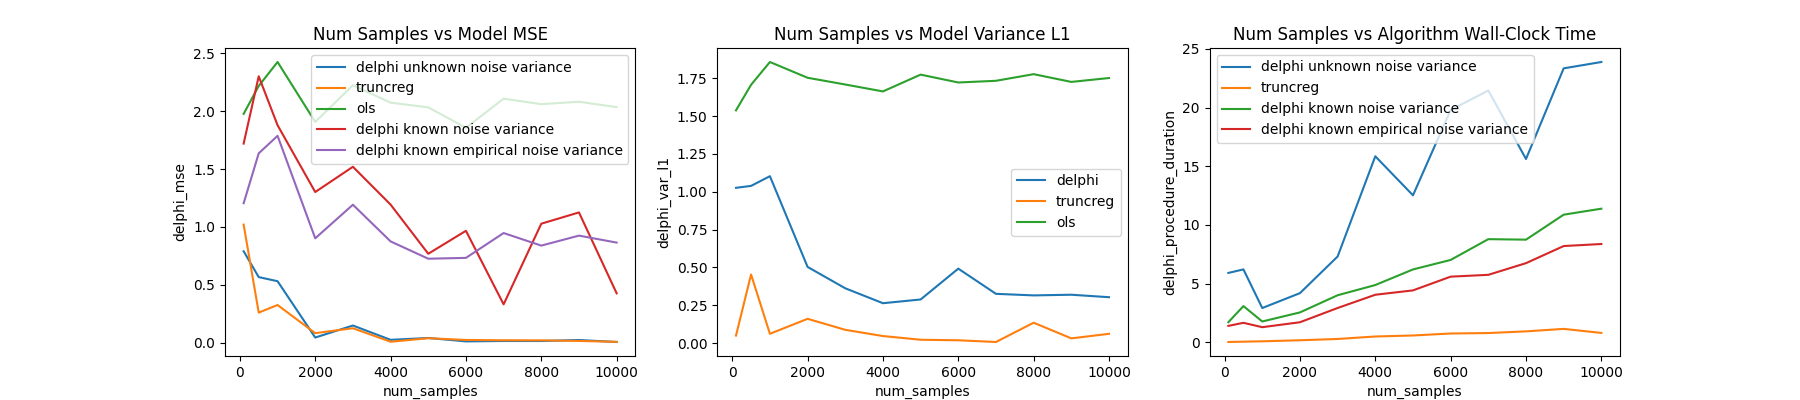

In [17]:
df = pd.DataFrame(results)

import seaborn as sns

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi unknown noise variance")
sns.lineplot(data=df, x="num_samples", y="truncreg_mse", estimator="mean", errorbar="sd", ax=ax1, label="truncreg")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax1, label="ols")
sns.lineplot(data=df, x="num_samples", y="delphi_known_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi known noise variance")
sns.lineplot(data=df, x="num_samples", y="delphi_emp_known_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi known empirical noise variance")
ax1.set_title('Num Samples vs Model MSE')

sns.lineplot(data=df, x="num_samples", y="delphi_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="delphi")
sns.lineplot(data=df, x="num_samples", y="truncreg_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="truncreg")
sns.lineplot(data=df, x="num_samples", y="emp_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="ols")
ax2.set_title('Num Samples vs Model Variance L1')

sns.lineplot(data=df, x="num_samples", y="delphi_procedure_duration", estimator="mean", errorbar="sd", ax=ax3, label="delphi unknown noise variance")
sns.lineplot(data=df, x="num_samples", y="truncreg_procedure_duration", estimator="mean", errorbar="sd", ax=ax3, label="truncreg")
sns.lineplot(data=df, x="num_samples", y="delphi_known_procedure_duration", estimator="mean", errorbar="sd", ax=ax3, label="delphi known noise variance")
sns.lineplot(data=df, x="num_samples", y="delphi_emp_known_procedure_duration", estimator="mean", errorbar="sd", ax=ax3, label="delphi known empirical noise variance")
ax3.set_title('Num Samples vs Algorithm Wall-Clock Time')

plt.show()

In [116]:
from delphi.grad import TruncatedUnknownVarianceMSE
trunc_mse = TruncatedUnknownVarianceMSE.apply
print(f'truncated estimates loss: {trunc_mse(x_trunc@delphi_[:-1][...,None] + delphi_[-1], y_trunc, 1/delphi_var_, phi).sum()}')
print(f'gt loss: {trunc_mse(x_trunc@gt_[:-1][...,None] + gt_[-1], y_trunc, 1/ch.Tensor([NOISE_VAR]), phi).sum()}')

NameError: name 'delphi_' is not defined

In [23]:
df

,num_samples,emp_mse,emp_var_l1,delphi_mse,delphi_var_l1,delphi_procedure_duration,delphi_known_mse,delphi_known_procedure_duration,delphi_emp_known_mse,delphi_emp_known_procedure_duration,truncreg_mse,truncreg_var_l1,truncreg_procedure_duration
0,100,0.265113,1.381436,0.167461,1.378377,None,0.122806,None,0.154092,None,0.174885,0.664342,0.019461
1,500,0.401917,1.316537,0.008081,0.534285,None,0.048138,None,0.071646,None,0.044987,0.191187,0.036084
2,1000,0.423029,1.129379,0.017004,0.043855,None,0.015994,None,0.073675,None,0.024783,0.403368,0.052305
3,2000,0.336268,1.171274,0.006751,0.222328,None,0.026520,None,0.092521,None,0.025362,0.021576,0.055969
4,3000,0.351498,1.128048,0.007884,0.058440,None,0.081711,None,0.134023,None,0.006387,0.134127,0.106606
5,4000,0.404787,1.202852,0.001918,0.054547,None,0.007957,None,0.132288,None,0.010350,0.064140,0.121108
6,5000,0.479441,1.180221,0.003826,0.075141,None,0.051455,None,0.112939,None,0.001393,0.012179,0.130358
7,6000,0.379656,1.226697,0.003071,0.152352,None,0.010023,None,0.078445,None,0.014168,0.097296,0.116889
8,7000,0.393497,1.197082,0.001728,0.015916,None,0.003416,None,0.187848,None,0.026219,0.114579,0.146088
9,8000,0.396557,1.188798,0.003797,0.182101,None,0.005179,None,0.103712,None,0.015354,0.014815,0.146902


In [162]:
gt_noise_var

tensor([3.0450])

In [163]:
delphi_var_

tensor(2.8814)

In [164]:
truncreg_var_

tensor([3.0181])

In [153]:
mse_loss(delphi_orig_, gt_orig_)

tensor(0.0008)

tensor(0.9728)

In [58]:
from delphi.utils.helpers import cov

In [139]:
gt_[:-1] / ch.sqrt(x_trunc_var)

tensor([0.9957, 0.9501])

In [144]:
gt_[-1] - (gt_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum()

tensor(1.0203)

In [136]:
gt_[-1] - x_trunc_mu

tensor([1.5096, 1.5165])

In [135]:
X_trunc_var

tensor([0.0806])

In [47]:
delphi_var_

tensor([3.1354])

In [46]:
gt_noise_var

tensor([3.0032])

In [74]:
truncreg_results
res = truncreg_results.rx('coefficients')[0]

In [87]:
sigma = ch.Tensor([res[-1]])

In [88]:
ch.Tensor(res[:-1]) * sigma

tensor([3.5769, 0.4080, 0.4148])

In [21]:
df = pd.DataFrame({
    'y': y_trunc.flatten(), 
    'x1': x_trunc[:,0].flatten(), 
#     'x2': x_trunc[:,1].flatten()
    
})

In [245]:
cutoff = ((1 - emp_[-1]) / ch.sqrt(emp_noise_var)).item()

truncreg_results = run_truncreg(df, 1, with_intercept=True)

> /tmp/ipykernel_22424/2907151852.py(33)run_truncreg()
     32     import ipdb; ipdb.set_trace()
---> 33     formula_string = ["y ~"] + [col for col in cols]
     34     if not with_intercept:

ipdb> c


In [246]:
truncreg_results.rx('coefficients')[0]

2.297674,0.734923,1.080415


In [26]:
delphi_reg.trainer.procedure_duration

In [32]:
delphi_reg.optimizer

SGD (
Parameter Group 0
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.05987369392383786
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0

Parameter Group 1
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.05987369392383786
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0
)

In [99]:

data = {
    'y': y_trunc.flatten().numpy()
}

for j in range(x_trunc.size(1)): 
    data['x' + str(j)] = x_trunc[:,j].flatten().numpy()

data = pd.DataFrame(data)

truncreg_results = run_truncreg(data, 1, with_intercept=True, scale=False)
res = truncreg_results.rx('coefficients')[0]

truncreg_coef_ = ch.Tensor(res[:-1])
truncreg_var_ = ch.Tensor([res[-1]]).pow(2)

scale: False


In [109]:
mse_loss(truncreg_coef_, ch.from_numpy(np.concatenate([gt_test.coef_.flatten(), gt_test.intercept_])))

tensor(0.0323)

In [104]:
gt_test = LinearRegression().fit(X, y)

In [145]:
        gt_orig = gt_[:-1] / ch.sqrt(x_trunc_var)
        gt_intercept_orig = gt_[-1] - (gt_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum()
        gt_orig_ = ch.cat([gt_orig, gt_intercept_orig.reshape(1,)])


In [158]:
mse_loss(emp_orig_, gt_orig_)

tensor(0.6832)

In [147]:
mse_loss(gt_orig_, truncreg_coef_)

tensor(0.0009)

In [148]:
truncreg_coef_

tensor([0.9462, 0.9660, 1.0196])

In [46]:
truncreg_results = run_truncreg(data, 1, with_intercept=True, scale=True)
res = truncreg_results.rx('coefficients')[0]

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages
  


In [29]:
mse_loss(delphi_, gt_)

tensor(0.1058)

In [14]:
delphi_reg.best_intercept_ * ch.sqrt(emp_noise_var) + emp_[-1]

tensor([3.7977])

In [193]:
truncreg_results

<rpy2.robjects.vectors.ListVector object at 0x767f10a2db10> [19]
R classes: ('truncreg', 'maxLik')
[FloatSexp..., FloatSexp..., FloatSexp..., FloatSexp..., ..., NULLType, IntSexpVe..., StrSexpVe..., ListSexpV...]
  coefficients: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x767f10abd410> [14]
R classes: ('numeric',)
[0.980293, 1.011092, 1.749787]
  vcov: <class 'rpy2.robjects.vectors.FloatMatrix'>
  <rpy2.robjects.vectors.FloatMatrix object at 0x767f10dae550> [14]
R classes: ('matrix', 'array')
[0.003559, -0.003898, -0.000786, -0.003898, ..., 0.000310, -0.000786, 0.000310, 0.000526]
  fitted.values: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x767f109d0110> [14]
R classes: ('numeric',)
[1.654403, 1.941527, 1.262178, 1.709789, ..., 1.289105, 1.314394, 1.208133, 1.686341]
  logLik: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x767f10832490> [14]
R classes: ('numeric',)
[-16125.996770]
...
  gradientObs: <class 'rpy2.rinterface_lib.sexp.NULLType'>
  <rpy2.rinterface_lib.sexp.NULLType object at 0x767f39c66f10> [0]
  nobs: <class 'rpy2.robjects.vectors.IntVector'>
  <rpy2.robjects.vectors.IntVector object at 0x767f10bcddd0> [13]
R classes: ('integer',)
[0]
  call: <class 'rpy2.robjects.vectors.StrVector'>
  <rpy2.robjects.vectors.StrVector object at 0x767f10bc2d10> [16]
R classes: ('character',)
['left']
<rpy2.robjects.vectors.ListVector object at 0x767f10a2db10> [19]
R classes: ('truncreg', 'maxLik')
[FloatSexp..., FloatSexp..., FloatSexp..., FloatSexp..., ..., NULLType, IntSexpVe..., StrSexpVe..., ListSexpV...]

In [20]:
args = Parameters({
                    'trials': 1,
                    'batch_size': 25,
                    'lr': 1e-1,
                    'early_stopping': True,
                    'step_lr_gamma': .95,
                    'step_lr': 1000,
                    'num_samples': 1000,
                    'optimizer': 'sgd',
                    'gradient_steps': max(1500, num_samples),
#                     'verbose': True,
})
delphi_known_reg = TruncatedLinearRegression(args,
                                        phi_emp_scale,
                                        alpha,
                                        noise_var=gt_noise_var/y_trunc_var,
                                        fit_intercept=True)
delphi_known_reg.fit(x_trunc_std, y_trunc_std)

delphi_known_coef_ = ch.cat([delphi_known_reg.best_coef_.flatten(), delphi_known_reg.best_intercept_[...,None]]) 

delphi_known_orig = delphi_known_coef_[:-1]*(ch.sqrt(y_trunc_var)/ch.sqrt(x_trunc_var))
delphi_known_intercept_orig = y_trunc_mu + ch.sqrt(y_trunc_var) * (delphi_known_coef_[-1] - (delphi_known_coef_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum())
delphi_known_orig_ = ch.cat([delphi_known_orig, delphi_known_intercept_orig.reshape(1,)])

In [21]:
delphi_known_orig_

tensor([0.7673, 0.5674, 0.5940, 0.6543, 0.6738, 0.6727, 0.7891, 0.6177, 0.6244,
        0.6624, 2.9362])

In [22]:
y_trunc_var

tensor([1.3730])

In [23]:
gt_noise_var

tensor([3.0053])

In [24]:
delphi_known_coef_

tensor([ 0.1862,  0.1389,  0.1458,  0.1595,  0.1643,  0.1635,  0.1921,  0.1508,
         0.1528,  0.1612, -0.9243])

In [43]:
x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, 1.0, W0=W0, D=D, verbose=True)

args = Parameters({
                    'trials': 1,
                    'batch_size': 100,
                    'lr': 1e-1,
                    'early_stopping': True,
                    'step_lr_gamma': .95,
                    'step_lr': 1000,
                    'num_samples': 1000,
                    'optimizer': 'sgd',
                    'gradient_steps': max(1500, num_samples),
#                     'verbose': True,
})
delphi_known_reg = TruncatedLinearRegression(args,
                                        phi,
                                        alpha,
                                        noise_var=gt_noise_var,
                                        fit_intercept=True)
delphi_known_reg.fit(x_trunc, y_trunc)

alpha: 0.504


TruncatedLinearRegression()

In [44]:
delphi_known_reg.best_coef_

tensor([0.4350, 0.4545, 0.4097, 0.4546, 0.4615, 0.4190, 0.3889, 0.4932, 0.4656,
        0.4844])

In [45]:
delphi_known_reg.best_intercept_

tensor(3.2337)

In [46]:
delphi_known_reg.optimizer

SGD (
Parameter Group 0
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.05987369392383786
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0
)

In [47]:
delphi_known_reg.final_coef_

tensor([0.7828, 0.8209, 0.7532, 0.8147, 0.8671, 0.7483, 0.6708, 0.9455, 0.8436,
        0.9184])

In [48]:
delphi_known_reg.final_intercept_

tensor(0.4674)